# Практическая работа №1

**Дискретизация и квантование сигналов. Дискретное преобразование Фурье**

Вариант 5: $y(t) = \cos(2\pi f t + \frac{\pi}{3}) + \sin(4\pi f t),\ f = 4$

In [139]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from icecream import ic

import numpy as np
import utils.debug
from matplotlib.axes import Axes

from utils.complex_numbers import to_polar, to_rect
from utils.harmonic import (
    get_harmonic_oscillation,
    get_period,
    get_phase_time_shift,
    get_phase_at,
)
from utils.spectrum import get_spectrum, get_spectrum_width
from utils.fourier import discrete_fourier_transform
from utils.quantize import quantize, quantize_np
from utils.plotting import show_multi_plot, show_plot
from utils.sampling import get_linspace
from scipy.io import wavfile
from IPython.display import Audio

In [140]:
sampling_frequency = 1024
start = 0
stop =  1
t = get_linspace(start=start, stop=stop, fs=sampling_frequency)

## Задание 1

Необходимо сгенерировать и визуализировать (вывести на график) непрерывный сигнал, в соответствии с вариантом (таблица 1.1). Номер варианта - порядковый номер в журнале группы.

ic| frequency: 4
ic| sampling_frequency: 1024


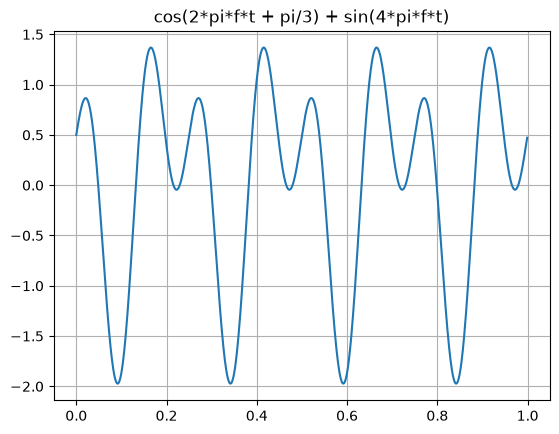

In [141]:
frequency = 4

ic(frequency)
ic(sampling_frequency)

y_1 = get_harmonic_oscillation(1, frequency, np.pi/3, wave=np.cos)(t)
y_2 = get_harmonic_oscillation(1, 2*frequency, 0, wave=np.sin)(t)
y = y_1 + y_2  # 5 вариант

show_plot(
    t=t,
    func_val=y,
    title="cos(2*pi*f*t + pi/3) + sin(4*pi*f*t)",
)

#### Вывод

Сигнал состоит из двух гармоник и повторяется каждую 1/4 секунды (период медленной гармоники 4 Гц), на графике это 4 одинаковых периода. Размах сигнала примерно от -2 до 1,4.

## Задание 2

Определить максимальную частоту в спектре данного сигнала.

**Расчёт.** Сигнал (варианта 5) состоит из двух гармоник:

$$y(t) = \cos(2\pi f t + \tfrac{\pi}{3}) + \sin(4\pi f t),\quad f = 4\ \text{Гц}$$

Частота каждой гармоники:

- $\cos(2\pi f t + \tfrac{\pi}{3})$: частота $f_1 = f = 4$ Гц;
- $\sin(4\pi f t) = \sin(2\pi \cdot 2f \cdot t)$: частота $f_2 = 2f = 8$ Гц.

Спектр сигнала состоит из этих двух частот, поэтому максимальная частота - наибольшая из них:

$$f_{max} = \max(f_1, f_2) = 2f = 2 \cdot 4 = 8\ \text{Гц}$$

In [142]:
max_freq = frequency * 2
ic(max_freq);

ic| max_freq: 8


## Задание 3

Определить минимальную необходимую частоту дискретизации полученного сигнала (теорема Котельникова).

In [143]:
# min_freq_kotelnikov = max_freq * 2
min_freq_kotelnikov = max_freq * 4

ic(max_freq)
ic(min_freq_kotelnikov);

ic| max_freq: 8
ic| min_freq_kotelnikov: 32


**Примечание.** По теореме Котельникова $f_s$ должна быть *строго больше* $2 f_{max}$. При $f_s = 2 f_{max} = 16$ Гц отсчёты восьмигерцовой гармоники $\sin(4\pi f t)$ попадают ровно в нули синуса, и она теряется.

Брать произвольное $f_s > 16$ Гц (например, 17 или 20) неудобно: сетка 1024 точки на 1 секунду не делится на такое число нацело, поэтому шаг `step` получается дробным и отсчёты получаются неравномерными.

Поэтому выбрано $f_s = 4 f_{max} = 32$ Гц: это ближайшая степень двойки выше минимума, она делит 1024 нацело (шаг 32), отсчёты равномерны.

## Задание 4

Оцифровать сигнал с полученной частотой дискретизации, выбрав требуемое число отсчетов сигнала на длительности 1 секунда, сохранить полученные значения в массив, пока не озадачиваясь разрядностью АЦП, просто выбранные с частотой дискретизации значения с теми уровнями, которые имеет функция в полученных точках.

In [144]:
step = len(y) // int(min_freq_kotelnikov * (stop - start))

# прореживая по шагу step
y_sampled = y[::step]
t_sampled = t[::step]

ic(y_sampled)
ic(t_sampled);

ic| y_sampled: array([ 0.5       ,  0.74118095, -0.8660254 , -1.96592583, -0.5       ,
                       1.25881905,  0.8660254 , -0.03407417,  0.5       ,  0.74118095,
                      -0.8660254 , -1.96592583, -0.5       ,  1.25881905,  0.8660254 ,
                      -0.03407417,  0.5       ,  0.74118095, -0.8660254 , -1.96592583,
                      -0.5       ,  1.25881905,  0.8660254 , -0.03407417,  0.5       ,
                       0.74118095, -0.8660254 , -1.96592583, -0.5       ,  1.25881905,
                       0.8660254 , -0.03407417])
ic| t_sampled: array([0.     , 0.03125, 0.0625 , 0.09375, 0.125  , 0.15625, 0.1875 ,
                      0.21875, 0.25   , 0.28125, 0.3125 , 0.34375, 0.375  , 0.40625,
                      0.4375 , 0.46875, 0.5    , 0.53125, 0.5625 , 0.59375, 0.625  ,
                      0.65625, 0.6875 , 0.71875, 0.75   , 0.78125, 0.8125 , 0.84375,
                      0.875  , 0.90625, 0.9375 , 0.96875])


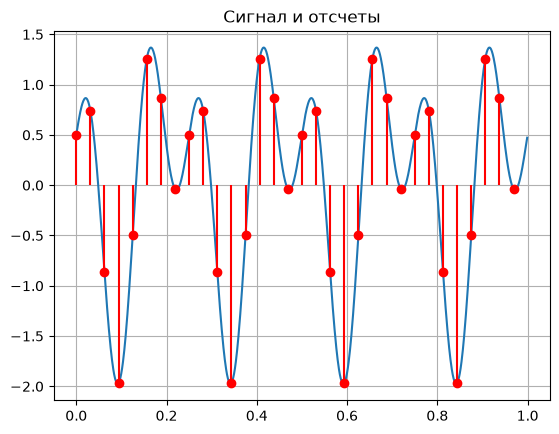

In [145]:
def draw_samples(ax: Axes) -> None:
    ax.stem(t_sampled, y_sampled, linefmt="r-", markerfmt="ro", basefmt=" ")

show_plot(
    t=t,
    func_val=y,
    title="Сигнал и отсчеты",
    on_axes=draw_samples,
)

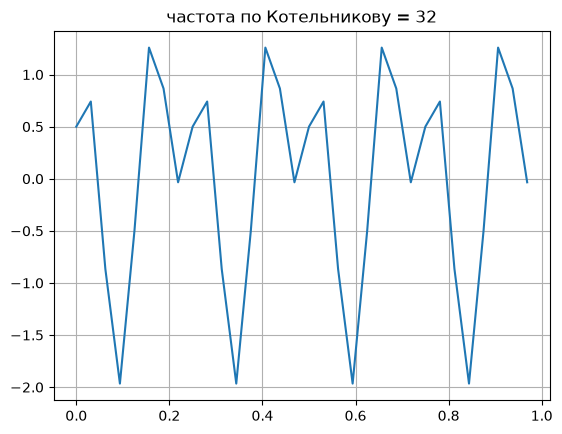

In [146]:
show_plot(
    t=t_sampled,
    func_val=y_sampled,
    title=f"частота по Котельникову = {min_freq_kotelnikov}",
)

#### Вывод

Взяли каждый 32-й отсчёт из 1024, получилось 32 отсчёта на секунду, то есть частота дискретизации 32 Гц. Обе гармоники сигнала по ним различимы.

## Задание 5

Выполнить прямое дискретное преобразование Фурье для массива временных отсчетов сигнала и оценить ширину данного спектра. А также объем памяти, требуемый для хранения данного массива (тип переменных в массиве - на ваше усмотрение, float, int и пр.).

### Что делает преобразование Фурье

Мы смотрим на сигнал и спрашиваем: Из каких гармоник он состоит?

Для этого мы используем прямое преобразование Фурье по формуле:

$$F(x) = \sum_{n=0}^{N-1} f(n)\, e^{-j 2\pi \frac{x n}{N}},$$

где $N$ - размерность преобразования Фурье, $F(x)$ - сигнал в частотной области и $f(n)$ - дискретизированный сигнал во временной области.

Листинг функции `utils/fourier.py`:

```python
def discrete_fourier_transform(x: np.ndarray) -> np.ndarray:
    N = len(x)
    X = []
    for k in range(N):
        s = 0
        for n in range(N):
            s += x[n] * np.exp(-2j * np.pi * k * n / N)
        X.append(s)

    return np.array(X)
```

**Что она возвращает.** Массив из `N` комплексных чисел (столько же, сколько отсчётов на входе). Число номер `k` относится к частоте номер `k`. Комплексное число хранит сразу две вещи: амплетуду и фазу.

**Как достать нужное:**

| Что нужно | Как получить | В коде |
|---|---|---|
| Частота `k`-й гармоники | номер умножить на шаг частоты | `k * fs / N` |
| Амплитуда (сила волны) | модуль комплексного числа, делённый на `N` | `np.abs(X) / N` |
| Фаза (сдвиг) | угол комплексного числа | `np.angle(X)` |

Из-за ошибок округления "ненужные" частоты получаются не ровно 0, а очень маленькими числами. Поэтому мы задаём порог `threshold` и считаем значимыми только те частоты, где амплитуда больше него.

**Что считать шириной спектра.** Это диапазон частот, в котором есть сигнал. Есть два способа считать:
- `max - min` - от самой низкой до самой высокой значимой частоты (у нас 4 и 8 Гц, получится 4 Гц). Так считают для полосовых сигналов, у которых спектр где-то посередине.
- `max` - от нуля до самой высокой частоты (получится 8 Гц). Так считают для сигналов в основной полосе, которые мы оцифровываем с нуля.

Я взял второй вариант: `f_max = 8` Гц.

In [147]:
y_dft = discrete_fourier_transform(y_sampled)
N = len(y_dft)
freqs = np.arange(N) * (min_freq_kotelnikov / N)
amp = np.abs(y_dft) / N

ic(freqs)
ic(amp)

threshold = 1e-6 # порог для выделения значимых частот
half = N // 2 + 1  # без зеркальной части
significant = np.array([freqs[k] for k in range(half) if amp[k] > threshold])
# spectrum_width = significant.max() - significant.min()
spectrum_width = significant.max()

ic(spectrum_width);

ic| freqs: array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
                  13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
                  26., 27., 28., 29., 30., 31.])
ic| amp: array([2.77555756e-17, 7.39993399e-17, 3.16461231e-17, 3.51614705e-16,
                5.00000000e-01, 3.94695830e-16, 1.97240692e-16, 1.54996458e-16,
                5.00000000e-01, 1.13698104e-16, 2.95841644e-16, 2.62533797e-16,
                3.64355492e-16, 8.13652846e-16, 5.08091498e-16, 3.89364649e-16,
                1.83568042e-15, 6.64082938e-16, 6.87560229e-16, 4.47316182e-16,
                3.45556987e-16, 3.87944218e-16, 3.95369749e-16, 1.23716373e-15,
                5.00000000e-01, 6.70588694e-16, 5.00919297e-16, 1.54605159e-15,
                5.00000000e-01, 1.29373207e-15, 6.35261403e-16, 3.62091088e-16])
ic| spectrum_width: np.float64(8.0)


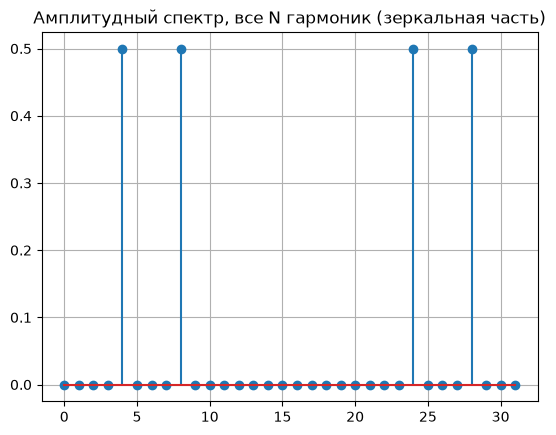

In [148]:
show_plot(
    t=freqs,
    func_val=amp,
    is_stem=True,
    title="Амплитудный спектр, все N гармоник (зеркальная часть)",
)

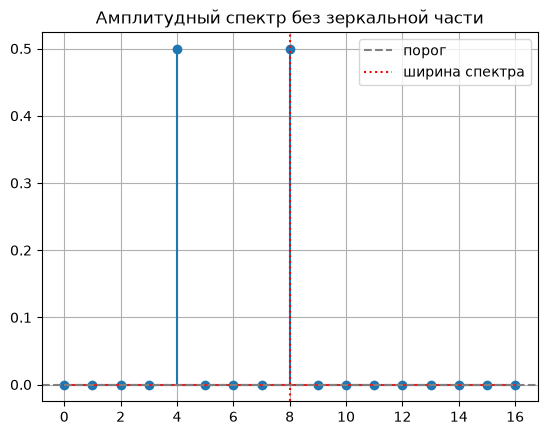

In [149]:
def draw_threshold(ax: Axes) -> None:
    ax.axhline(threshold, color="gray", linestyle="--", label="порог")
    ax.axvline(spectrum_width, color="r", linestyle=":", label="ширина спектра")
    ax.legend()

show_plot(
    t=freqs[:half],
    func_val=amp[:half],
    is_stem=True,
    title="Амплитудный спектр без зеркальной части",
    on_axes=draw_threshold,
)

#### Объём памяти для y_sampled

In [150]:
ic(y_sampled.dtype)   # float64 - 64 бита / 8 байт на отсчёт
ic(y_sampled.size)    # 32 отсчёта (fs = 32 Гц на 1 с)
ic(y_sampled.nbytes);  # 256 байт = 32 * 8

ic| y_sampled.dtype: dtype('float64')
ic| y_sampled.size: 32
ic| y_sampled.nbytes: 256


#### Объём памяти для y_dft

In [151]:
ic(y_dft.dtype)   # complex128 - 128 бит / 16 байт на отсчёт
ic(y_dft.size)    # 32 отсчёта (fs = 32 Гц на 1 с)
ic(y_dft.nbytes); # 512 байт = 32 * 16

ic| y_dft.dtype: dtype('complex128')
ic| y_dft.size: 32
ic| y_dft.nbytes: 512


#### Вывод

- В спектре две гармоники: на 4 Гц и на 8 Гц.
- Остальные частоты равны нулю (с точностью до ошибок округления), поэтому ширина спектра равна 8 Гц, как и максимальная частота из задания 2.
- Для хранения 32 отсчётов в `float64` нужно 256 байт, для их спектра в `complex128` - 512 байт.

## Задание 6

Восстановите оригинальный аналоговый сигнал по массиву имеющихся у вас отсчетов, соединив их непрерывной линией и оцените визуальное сходство оригинального сигнала и восстановленного после оцифровки.

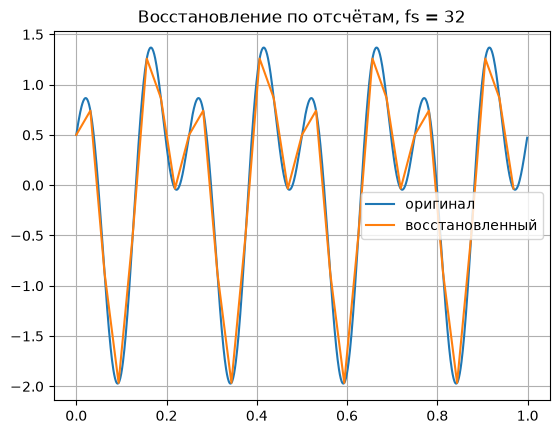

In [152]:
show_multi_plot(
    t=[t, t_sampled],
    func_vals=[y, y_sampled],
    labels=["оригинал", "восстановленный"],
    title=f"Восстановление по отсчётам, fs = {min_freq_kotelnikov}",
)

In [153]:
y_restored = np.interp(t, t_sampled, y_sampled)
mask = t <= t_sampled[-1]  # только там, где есть отсчёты с обеих сторон
restore_error = np.mean(np.abs(y[mask] - y_restored[mask]))

ic(restore_error);

ic| restore_error: np.float64(0.13764728860662287)


#### Вывод

Восстановленный сигнал повторяет форму оригинала, но в виде ломаной линии, потому что на период самой быстрой гармоники (8 Гц) приходится всего 4 отсчёта. Частота по Котельникову гарантирует, что информация о сигнале сохранена, но простое соединение точек прямыми восстанавливает его грубо.

## Задание 7

Увеличьте частоту дискретизации в 4 раза и проделайте задания из п.4-6.

### Пункт 4 (fs × 4)

In [154]:
min_freq_4x = min_freq_kotelnikov * 4
step_4x = len(y) // int(min_freq_4x * (stop - start))

y_sampled_4x = y[::step_4x]
t_sampled_4x = t[::step_4x]

ic(min_freq_4x)
ic(step_4x)
ic(y_sampled_4x.size);

ic| min_freq_4x: 128
ic| step_4x: 8
ic| y_sampled_4x.size: 128


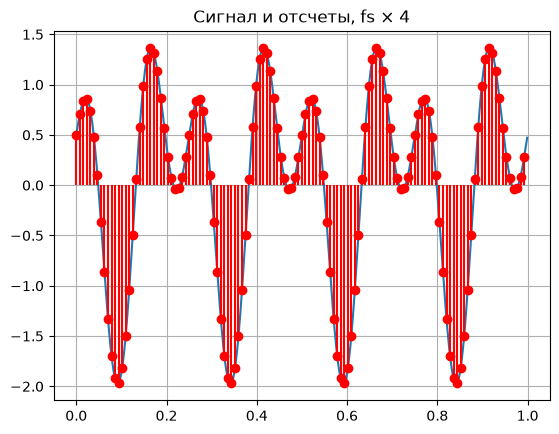

In [155]:
def draw_samples_4x(ax: Axes) -> None:
    ax.stem(t_sampled_4x, y_sampled_4x, linefmt="r-", markerfmt="ro", basefmt=" ")

show_plot(
    t=t,
    func_val=y,
    title="Сигнал и отсчеты, fs × 4",
    on_axes=draw_samples_4x,
)

### Пункт 5 (fs × 4)

In [156]:
y_dft_4x = discrete_fourier_transform(y_sampled_4x)
N_4x = len(y_dft_4x)
freqs_4x = np.arange(N_4x) * (min_freq_4x / N_4x)
amp_4x = np.abs(y_dft_4x) / N_4x

half_4x = N_4x // 2 + 1  # без зеркальной части
significant_4x = np.array([freqs_4x[k] for k in range(half_4x) if amp_4x[k] > threshold])
spectrum_width_4x = significant_4x.max()

ic(spectrum_width_4x)
ic(y_sampled_4x.nbytes);

ic| spectrum_width_4x: np.float64(8.0)
ic| y_sampled_4x.nbytes: 1024


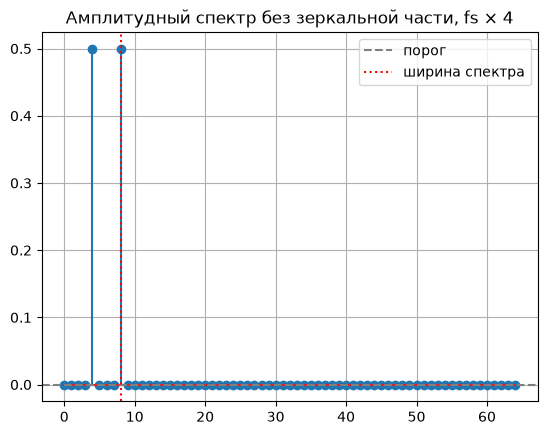

In [157]:
def draw_threshold_4x(ax: Axes) -> None:
    ax.axhline(threshold, color="gray", linestyle="--", label="порог")
    ax.axvline(spectrum_width_4x, color="r", linestyle=":", label="ширина спектра")
    ax.legend()

show_plot(
    t=freqs_4x[:half_4x],
    func_val=amp_4x[:half_4x],
    is_stem=True,
    title="Амплитудный спектр без зеркальной части, fs × 4",
    on_axes=draw_threshold_4x,
)

### Пункт 6 (fs × 4)

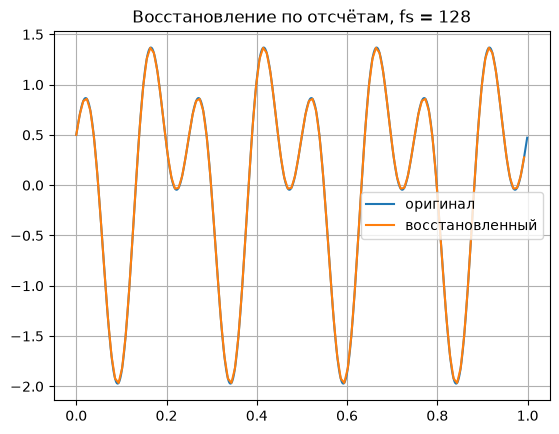

In [158]:
show_multi_plot(
    t=[t, t_sampled_4x],
    func_vals=[y, y_sampled_4x],
    labels=["оригинал", "восстановленный"],
    title=f"Восстановление по отсчётам, fs = {min_freq_4x}",
)

In [159]:
y_restored_4x = np.interp(t, t_sampled_4x, y_sampled_4x)
mask_4x = t <= t_sampled_4x[-1]  # только там, где есть отсчёты с обеих сторон
restore_error_4x = np.mean(np.abs(y[mask_4x] - y_restored_4x[mask_4x]))

ic(restore_error_4x);

ic| restore_error_4x: np.float64(0.008166292192515932)


#### Что изменилось

- Отсчётов стало в 4 раза больше, поэтому и памяти нужно в 4 раза больше.
- Восстановленная линия стала гораздо ближе к оригиналу.

## Задание 8

Запишите аудиофайл со своим голосом (например, в формате wav). Проанализируйте визуально спектр голоса, используя, например, приложение Audacity (вкладки Анализ -> График спектра). Определите максимальную частоту в спектре данного сигнала и выберите требуемую для оцифровки частоту дискретизации.

Запись голоса `voice.wav` (6,14 с, 44100 Гц, моно).

![Временное и частотное представление голоса в Audacity](Screenshot_1.png)

*Временное и частотное представление голоса в Audacity (Анализ -> График спектра).*

<audio controls src="voice.wav"></audio>

*Запись голоса `voice.wav`.*

#### Максимальная частота и частота дискретизации

На графике видно, что почти вся энергия голоса сосредоточена в низких частотах, а дальше спектр спадает. Заметный голосовой спектр заканчивается примерно на частоте $f_{max} \approx 6200$ Гц (курсор на: 6223 Гц, -71 дБ). Дальше идёт уровень шума, там самого голоса уже нет.

По теореме Котельникова частота дискретизации должна быть строго больше удвоенной максимальной частоты:

$$f_s > 2 f_{max} = 2 \cdot 6200 = 12400\ \text{Гц}$$

Значит, для оцифровки такого голоса достаточно, например, $f_s = 16000$ Гц.

## Задание 9

Используя библиотеки работы со звуком Matlab (или Pyton) проанализируйте имеющуюся у вас запись голоса. Считайте аудиофайл с помощью функции Matlab (файл с голосом должен лежать в рабочей директории Matlab):

```matlab
[y, Fs] = audioread('voice.wav');
```

где y - это массив отсчетов голоса, а Fs - частота дискретизации или семплирования, которая определяется в Matlab для данного файла.

In [160]:
Fs, y_voice = wavfile.read("voice.wav")

if y_voice.ndim > 1:
    y_voice = y_voice[:, 0]

if np.issubdtype(y_voice.dtype, np.integer):
    y_voice = y_voice / np.iinfo(y_voice.dtype).max  # приводим к диапазону -1..1

ic(Fs)
ic(y_voice.size);

ic| Fs: 44100
ic| y_voice.size: 270848


## Задание 10

Определите частоту дискретизации, которая была использована при записи голоса на цифровой носитель. Для этого возьмите количество элементов в файле с записью и разделите на длительность записи в секундах. Например, если у вас файл состоит из 441 000 элементов (отсчетов) и имеет длительность 10 секунд, то частота дискретизации Fs будет равна 441 000/10 = 44 100 Гц. Сравните вычисленное значение с тем, что выводится в Matlab для Fs.

In [161]:
# duration = y_voice.size / Fs
duration = 6.141678004535147

Fs_calc = y_voice.size / duration

ic(duration)
ic(Fs_calc)
ic(Fs);

ic| duration: 6.141678004535147
ic| Fs_calc: 44100.0
ic| Fs: 44100


#### Вывод

Частота дискретизации, посчитанная как число отсчётов, делённое на длительность, совпала с той, что вернула `wavfile.read`, и равна 44100 Гц.

## Задание 11

Проредите полученный массив y с помощью функции downsample (иными словами - уменьшите частоту дискретизации) и воспроизведите полученный сигнал с помощью matlab-функции play() или ее аналогами в других языках программирования. Обратите внимание на качество звучания при неверно взятой частоте дискретизации:

```matlab
y1=downsample(y, 10); % прореживаем массив y, оставляя лишь каждый 10й отсчет
zvuk = audioplayer(y1,Fs/10); %создаем объект gong типа audioplayer
play(zvuk); %воспроизводим звук
plot(y1); %визуализируем амплитуду сигнала на графике в зависимости от времени
```

Чтобы остановить воспроизведение звука, введите stop(zvuk) в командную строку.

In [162]:
Fs_down = Fs // 10
y_voice_down = y_voice[::10]

ic(Fs_down)
ic(y_voice_down.size);

ic| Fs_down: 4410
ic| y_voice_down.size: 27085


#### Оригинал

In [163]:
ic(Fs)
Audio(y_voice, rate=Fs)

ic| Fs: 44100


#### Прореженный сигнал

In [164]:
ic(Fs_down)
Audio(y_voice_down, rate=Fs_down)

ic| Fs_down: 4410


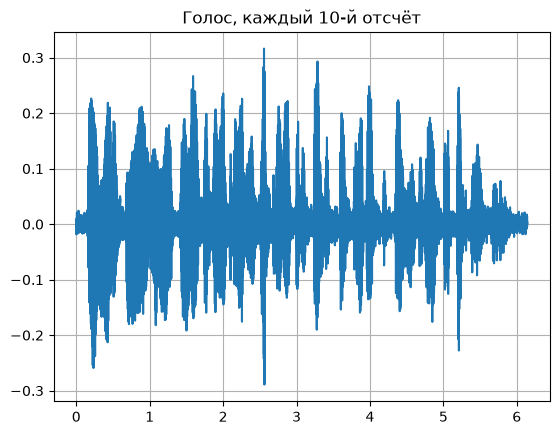

In [165]:
t_voice_down = np.arange(y_voice_down.size) / Fs_down

show_plot(
    t=t_voice_down,
    func_val=y_voice_down,
    title="Голос, каждый 10-й отсчёт",
)

#### Вывод

Оригинал звучит чисто. Прореженный сигнал звучит глухо, с искажениями: мы оставили только 4410 отсчётов в секунду, а голосу нужно хотя бы 14 кГц (по теореме Котельникова). Это и есть последствия неверно выбранной частоты дискретизации.

## Задание 12

Выполните прямое дискретное преобразование Фурье для оригинального звучания и для прореженного сигнала, выведите на график амплитудный спектр сигнала, определите его ширину.

`discrete_fourier_transform` считает за `N²` операций, а у записи сотни тысяч отсчётов. Поэтому для ускорения я взял готовую реализацую быстрого преобразования Фурье `np.fft.fft`.

Ширину спектра у голоса ровно до нуля не найти, поэтому считаем значимыми частоты, где амплитуда больше 1% от самой большой.

```python
def get_spectrum(x: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray]:
    N = len(x)
    # X = discrete_fourier_transform(x)
    X = np.fft.fft(x)
    half = N // 2 + 1  # без зеркальной части

    return np.arange(half) * (fs / N), np.abs(X[:half]) / N


def get_spectrum_width(freqs: np.ndarray, amp: np.ndarray, level: float = 0.01) -> float:
    return freqs[amp > level * amp.max()].max()
```

In [166]:
freqs_voice, amp_voice = get_spectrum(y_voice, Fs)
freqs_voice_down, amp_voice_down = get_spectrum(y_voice_down, Fs_down)

width_voice = get_spectrum_width(freqs_voice, amp_voice)
width_voice_down = get_spectrum_width(freqs_voice_down, amp_voice_down)

ic(width_voice)
ic(width_voice_down);

ic| width_voice: np.float64(7057.02903473535)
ic| width_voice_down: np.float64(2204.7557688757615)


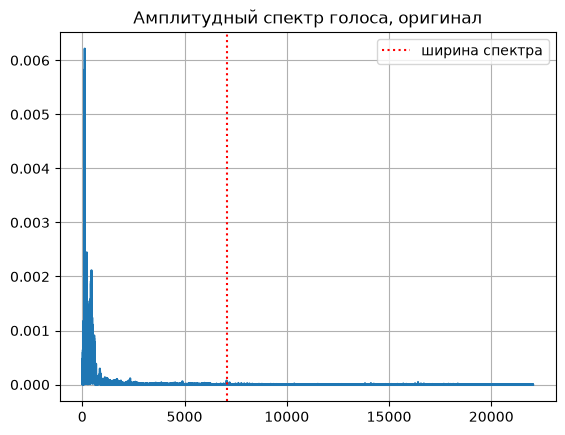

In [167]:
def draw_width_voice(ax: Axes) -> None:
    ax.axvline(width_voice, color="r", linestyle=":", label="ширина спектра")
    ax.legend()

show_plot(
    t=freqs_voice,
    func_val=amp_voice,
    title="Амплитудный спектр голоса, оригинал",
    on_axes=draw_width_voice,
)

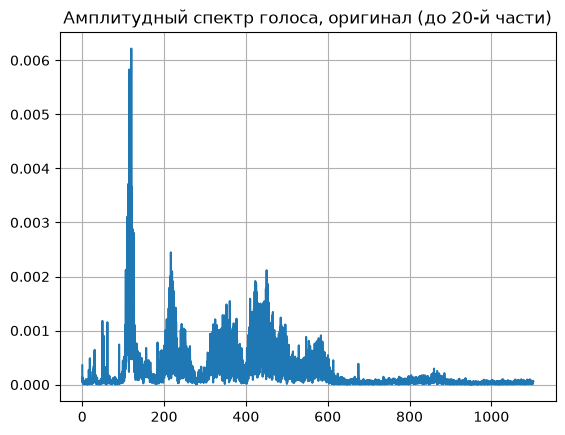

In [168]:
show_plot(
    t=freqs_voice[:len(freqs_voice)//20],
    func_val=amp_voice[:len(amp_voice)//20],
    title="Амплитудный спектр голоса, оригинал (до 20-й части)"
)

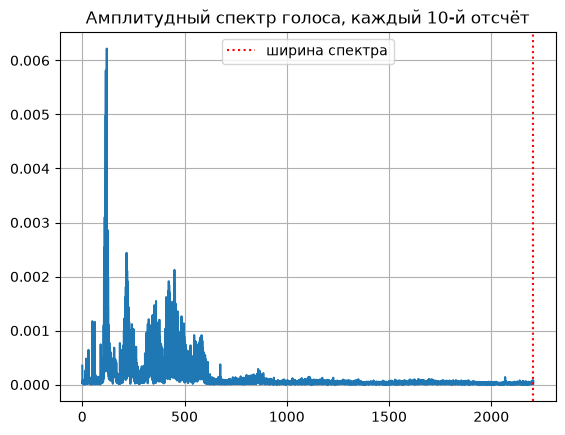

In [169]:
def draw_width_voice_down(ax: Axes) -> None:
    ax.axvline(width_voice_down, color="r", linestyle=":", label="ширина спектра")
    ax.legend()

show_plot(
    t=freqs_voice_down,
    func_val=amp_voice_down,
    title="Амплитудный спектр голоса, каждый 10-й отсчёт",
    on_axes=draw_width_voice_down,
)

#### Вывод

- Основная энергия голоса лежит в самых низких частотах (до нескольких сотен герц), дальше амплитуды спектра быстро падают.
- У оригинала (44100 Гц) ширина спектра около 7 кГц, это согласуется с Audacity (задание 8).
- После прореживания в 10 раз частота дискретизации стала 4410 Гц, и спектр обрезан на 2205 Гц (половина от новой частоты). Всё, что в голосе было выше, потерялось или "сложилось" с нижними частотами, поэтому звук стал глухим и "шакальным".

## Задание 13

Оцените влияние разрядности АЦП на спектр сигнала. Для этого нужно написать функцию, которая бы округляла значения отсчетов сигнала, заданного в вашем варианте, до какого-то числа, определяемого разрядностью АЦП. Допустим если у АЦП всего 3 разряда, то диапазон возможных дискретных значений амплитуд временных отсчетов сигнала - это 0..7 (то есть, $7=2^3-1$). Все значения больше 7 округляются до 7. Для результирующего дискретного сигнала требуется выполнить прямое преобразование Фурье. Сравнить полученный спектр со спектром исходной синусоиды, отсчеты которой не подвергались квантованию по уровню. Вывести среднюю ошибку квантования для случаев, когда разрядность АЦП равна 3/4/5/6.

#### Как работает квантование

У АЦП с `bits` разрядами есть всего `2^bits` уровней (коды `0..2^bits - 1`). Наш сигнал бывает и отрицательным, поэтому сначала мы сдвигаем и растягиваем его так, чтобы он занял диапазон `0..2^bits - 1`, округляем до целого (это и есть код АЦП), всё, что вылезло за диапазон, обрезаем, и возвращаем обратно в исходный масштаб, чтобы можно было сравнивать с оригиналом.

Ошибка квантования - разница между исходным отсчётом и тем, что получилось после округления. Средняя ошибка - среднее модуля этой разницы.

In [170]:
bits_list = [3, 4, 5, 6]
quantized = {bits: quantize(y_sampled, bits) for bits in bits_list}
quant_errors = {bits: np.mean(np.abs(y_sampled - quantized[bits])) for bits in bits_list}

ic(y_sampled.max())
ic(y_sampled.min())
ic("---------------------")

for bits in bits_list:
    ic(bits)
    ic(quant_errors[bits])
    ic("---------------------")

ic| y_sampled.max(): np.float64(1.2588190451025218)
ic| y_sampled.min(): np.float64(-1.965925826289069)
ic| '---------------------'
ic| bits: 3
ic| quant_errors[bits]: np.float64(0.07986980422058564)
ic| '---------------------'
ic| bits: 4
ic| quant_errors[bits]: np.float64(0.036611652351682206)
ic| '---------------------'
ic| bits: 5
ic| quant_errors[bits]: np.float64(0.019374196344376298)
ic| '---------------------'
ic| bits: 6
ic| quant_errors[bits]: np.float64(0.011018439086669527)
ic| '---------------------'


#### Спектры после квантования

На каждом графике палочки - спектр квантованного сигнала, красные точки - спектр исходного.

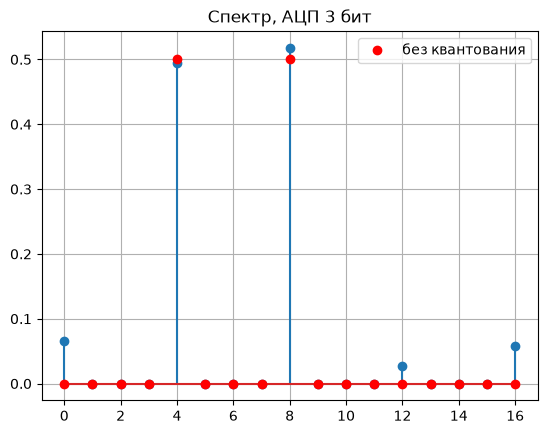

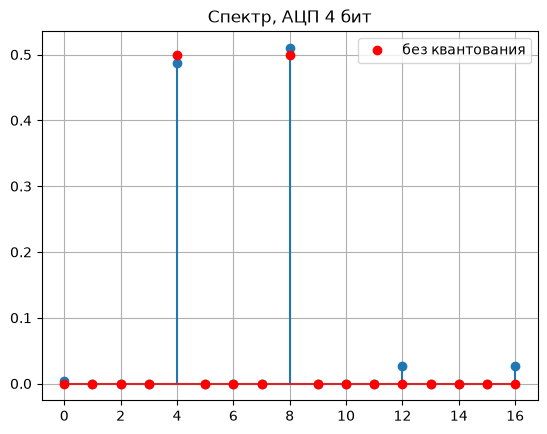

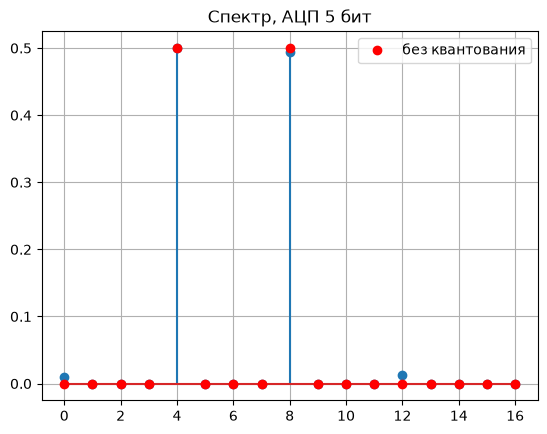

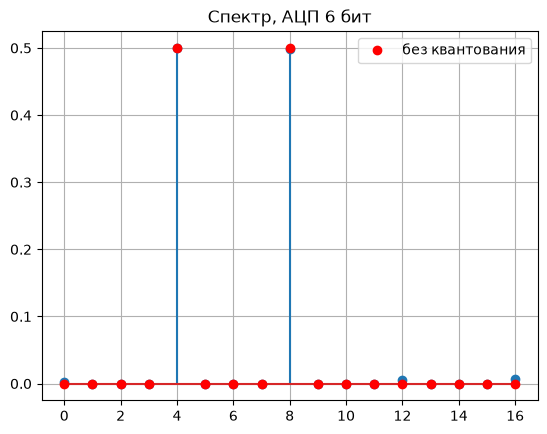

In [171]:
def get_half_amp(x: np.ndarray) -> np.ndarray:
    return np.abs(discrete_fourier_transform(x))[:half] / len(x)

amp_origin = get_half_amp(y_sampled)

for bits in bits_list:
    def draw_origin(ax: Axes) -> None:
        ax.plot(freqs[:half], amp_origin, "ro", label="без квантования")
        ax.legend()

    show_plot(
        t=freqs[:half],
        func_val=get_half_amp(quantized[bits]),
        is_stem=True,
        title=f"Спектр, АЦП {bits} бит",
        on_axes=draw_origin,
    )

#### Вывод

Чем больше разрядов у АЦП, тем меньше средняя ошибка квантования (каждый лишний разряд примерно вдвое уменьшает её). На спектре ошибка выглядит как "шум" - маленькие палочки на частотах, где в исходном сигнале ничего нет. С ростом разрядности этот шум падает, а основные пики (4 и 8 Гц) почти не меняются.

## Контрольные вопросы и задания

**1) Для чего используются прямое и обратное преобразование Фурье?**

Прямое преобразование Фурье переводит сигнал из временного представления в частотное: показывает, из каких гармоник он состоит и какие у них амплитуды и фазы. Обратное делает наоборот: по частотному представлению восстанавливает сигнал во времени. Вместе они позволяют анализировать спектр сигнала, фильтровать его в частотной области и возвращаться обратно.

**2) Что такое ошибка квантования и дискретизации?**

Ошибка дискретизации возникает из-за того, что мы берём сигнал только в отдельные моменты времени. Если частота дискретизации слишком мала (не выполняется теорема Котельникова), часть информации теряется, а высокие частоты "складываются" с низкими. Ошибка квантования возникает из-за того, что амплитуду отсчёта приходится округлять до одного из $2^n$ уровней АЦП. Она не превышает половины шага квантования и тем меньше, чем больше разрядов у АЦП.

**3) Какое количество разрядов АЦП требуется, чтобы оцифровать голос?**

Для разборчивой речи (телефонная связь) хватает 8 разрядов. Для качественной записи обычно берут 16 разрядов: это 65536 уровней и динамический диапазон около 96 дБ.

**4) Как математически получить дискретные отсчеты непрерывного сигнала?**

Нужно взять значения непрерывной функции в моменты времени, кратные периоду дискретизации $T_s = 1/f_s$:

$$x[n] = x(nT_s) = x\left(\frac{n}{f_s}\right),\quad n = 0, 1, 2, \dots$$

В коде это то же самое, что делать срез `y[::step]`.

**5) Какой спектр у периодического сигнала sin(10πt+π/2)?**

Так как $\sin(10\pi t + \pi/2) = \sin(2\pi \cdot 5 \cdot t + \pi/2) = \cos(10\pi t)$, это одна гармоника с частотой $f = 5$ Гц и амплитудой 1. Спектр состоит из одной линии на 5 Гц (в полном спектре ещё зеркальная линия на -5 Гц, каждая с амплитудой 0,5), начальная фаза $\pi/2$ у синусной формы записи.

**6) Что такое быстрое преобразование Фурье?**

Это алгоритм, который считает то же дискретное преобразование Фурье, но быстрее. Он использует повторяющиеся значения синуса и косинуса и группирует слагаемые с одинаковыми множителями. Вместо порядка $N^2$ операций нужно порядка $N \log_2 N$, а длина входа обычно равна степени двойки ($N = 2^k$). Поэтому БПФ используют в реальных модемах.

**7) Как определяется минимальная требуемая для оцифровки частота дискретизации сигнала?**

По теореме Котельникова: частота дискретизации должна быть строго больше удвоенной максимальной частоты в спектре сигнала,

$$f_s > 2 f_{max}.$$